In [1]:
import sys
import os
import csv
import h5py

# Add parent and grandparent directories to sys.path
sys.path.insert(0, '..')
sys.path.insert(0, '../..')

import numpy as np
from scipy import linalg
from scipy.linalg import expm
from scipy.stats import qmc

import math

from collections import Counter

import matplotlib.pyplot as plt
import seaborn as sns

import random

from src import density_matrix as DM
from src import ket

FIGURES_FILEPATH = '../QuNet_bootcamp_2025/Session_7/NM_figures/'

# Deterministic

In [2]:
def generate_all_gate_seqs(gates, rule_len):
    gate_seqs = [[]]
    for i in range(rule_len):
        gate_seqs = [x + [g] for x in gate_seqs for g in gates] # TODO: generalize to longer patterns 

    gate_seqs = [tuple(x) for x in gate_seqs]

    return gate_seqs 

def generate_seq_rules_deterministic(gates = ['j','g'],rule_len = 2):
    '''
    Generate rules for generating sequence based on previous two steps (deterministic).
    '''

    gate_seqs = generate_all_gate_seqs(gates = gates, rule_len = rule_len)

    gate_dests = [[]]
    for i in range(len(gate_seqs)):
        gate_dests = [x + [g] for x in gate_dests for g in gates]

    two_gram_rules = []
    for dests in gate_dests: 
        rule = {key: value for key, value in zip(gate_seqs, dests)} 
        two_gram_rules.append(rule)

    return two_gram_rules, gate_seqs

two_gram_rules_det, two_gate_seqs = generate_seq_rules_deterministic(rule_len = 2)
three_gram_rules_det, three_gate_seqs = generate_seq_rules_deterministic(rule_len = 3)
two_gram_rules_det

[{('j', 'j'): 'j', ('j', 'g'): 'j', ('g', 'j'): 'j', ('g', 'g'): 'j'},
 {('j', 'j'): 'j', ('j', 'g'): 'j', ('g', 'j'): 'j', ('g', 'g'): 'g'},
 {('j', 'j'): 'j', ('j', 'g'): 'j', ('g', 'j'): 'g', ('g', 'g'): 'j'},
 {('j', 'j'): 'j', ('j', 'g'): 'j', ('g', 'j'): 'g', ('g', 'g'): 'g'},
 {('j', 'j'): 'j', ('j', 'g'): 'g', ('g', 'j'): 'j', ('g', 'g'): 'j'},
 {('j', 'j'): 'j', ('j', 'g'): 'g', ('g', 'j'): 'j', ('g', 'g'): 'g'},
 {('j', 'j'): 'j', ('j', 'g'): 'g', ('g', 'j'): 'g', ('g', 'g'): 'j'},
 {('j', 'j'): 'j', ('j', 'g'): 'g', ('g', 'j'): 'g', ('g', 'g'): 'g'},
 {('j', 'j'): 'g', ('j', 'g'): 'j', ('g', 'j'): 'j', ('g', 'g'): 'j'},
 {('j', 'j'): 'g', ('j', 'g'): 'j', ('g', 'j'): 'j', ('g', 'g'): 'g'},
 {('j', 'j'): 'g', ('j', 'g'): 'j', ('g', 'j'): 'g', ('g', 'g'): 'j'},
 {('j', 'j'): 'g', ('j', 'g'): 'j', ('g', 'j'): 'g', ('g', 'g'): 'g'},
 {('j', 'j'): 'g', ('j', 'g'): 'g', ('g', 'j'): 'j', ('g', 'g'): 'j'},
 {('j', 'j'): 'g', ('j', 'g'): 'g', ('g', 'j'): 'j', ('g', 'g'): 'g'},
 {('j'

In [3]:
def generate_seq_from_rule_det(rule : dict, init : list, max_steps : int):
    '''
    Generate gate sequences given a rule. 

    Parameters
    ----------
    rule : dictionary where keys correspond to previous pattern to match, values
            correspond to next element of sequence to generate. 
    init : initial list of gates to start from. 
    gates : list of all gates. 
    '''

    # check that all keys in rule are of equal length
    pattern_len = len(list(rule.keys())[0])
    for key in rule.keys():
        if len(key) != pattern_len:
            raise Exception('Length of pattern to match is not equal.')
    
    # check that initial sequence is at least as long as pattern-to-match
    if len(init) < pattern_len:
        raise Exception('Initial string must be greater or equal to pattern length.')

    # generate new sequence based on rule
    pattern_prev = tuple(init[-pattern_len:])
    gen_seq = init.copy()

    for i in range(max_steps): 
        gen_seq.append(rule[pattern_prev])
        pattern_prev = tuple(gen_seq[-pattern_len:])
    
    return gen_seq

In [4]:
def principal_period(inputv):
    if not inputv:
        return inputv

    nxt = [0]*len(inputv)
    for i in range(1, len(nxt)):
        k = nxt[i - 1]
        while True:
            if inputv[i] == inputv[k]:
                nxt[i] = k + 1
                break
            elif k == 0:
                nxt[i] = 0
                break
            else:
                k = nxt[k - 1]

    smallPieceLen = len(inputv) - nxt[-1]
    if len(inputv) % smallPieceLen != 0:
        return inputv

    return inputv[0:smallPieceLen]

In [5]:
def find_interesting_rules(init_seq, rules, printing=True):
    n_pattern = len(list(rules[0].keys())[0])
    interesting_rules = []
    patterns = []
    for i in range(len(rules)): 
        seq = generate_seq_from_rule_det(rule = rules[i], init = init_seq, max_steps = 50)
        combined_str = ''.join(seq)
        pattern = principal_period(combined_str[-3 * math.factorial(n_pattern):])
        if len(pattern) > n_pattern:
            interesting_rules.append(i)
            patterns.append(pattern) 
            if printing: 
                print(f'{i}: {combined_str}')
    
    return interesting_rules, patterns

In [6]:
# find interesting two gate seqs (three-gram) rules
for seq in two_gate_seqs:
    init_seq = list(seq)
    idx, patts = find_interesting_rules(init_seq, two_gram_rules_det,printing=False)
    print(idx, patts)
    if seq == two_gate_seqs[0]: 
        two_gate_res = idx
    two_gate_res = list(set(two_gate_res) & set(idx))

two_gate_res

[8, 9, 12, 14] ['jgj', 'jgj', 'ggjjgg', 'jgg']
[6, 8, 9, 12, 14] ['ggj', 'gjj', 'gjj', 'gjjggj', 'ggj']
[6, 8, 9, 12, 14] ['jgg', 'jjg', 'jjg', 'jggjjg', 'jgg']
[6, 8, 12, 14] ['gjg', 'gjj', 'jjggjj', 'gjg']


[8, 12, 14]

In [7]:
two_gate_init_seqs = [list(x) for x in two_gate_seqs]
for init_seq in two_gate_init_seqs: 
    print(''.join(generate_seq_from_rule_det(rule = two_gram_rules_det[14], init = init_seq, max_steps = 50)))

jjggjggjggjggjggjggjggjggjggjggjggjggjggjggjggjggjgg
jggjggjggjggjggjggjggjggjggjggjggjggjggjggjggjggjggj
gjggjggjggjggjggjggjggjggjggjggjggjggjggjggjggjggjgg
ggjggjggjggjggjggjggjggjggjggjggjggjggjggjggjggjggjg


In [8]:
# save some interesting deterministic sequences
gen_seq_len = 500
folder_name = 'non_markovian_orders_list'

for num in two_gate_res:
    rule = two_gram_rules_det[num] # obtain rule 
    list_seq = []

    name = 'rule_' + '_'.join(list(rule.values()))
        
    for init_seq in two_gate_init_seqs: 
        seq = generate_seq_from_rule_det(rule = rule, init = init_seq, max_steps = gen_seq_len)
        seq = ''.join(seq)
        list_seq.append(seq)

    file_name = f'../{folder_name}/{name}.csv'
    with open(file_name, "w") as file:
        file.write(",\n".join(list_seq))

In [9]:
for seq in three_gate_seqs:
    init_seq = list(seq)
    idx, patts = find_interesting_rules(init_seq, three_gram_rules_det,printing=False)
    print(idx, patts)
    if seq == three_gate_seqs[0]: 
        three_gate_res = idx
    three_gate_res = list(set(three_gate_res) & set(idx))

len(three_gate_res)

[128, 129, 130, 131, 132, 133, 134, 135, 144, 145, 146, 147, 148, 149, 150, 151, 164, 165, 172, 173, 180, 182, 188, 190, 192, 193, 194, 195, 196, 197, 200, 201, 202, 203, 204, 205, 208, 210, 212, 214, 216, 218, 220, 222, 224, 225, 228, 229, 232, 233, 236, 237, 240, 244, 246, 248, 252, 254] ['gjjjgjjjgjjjgjjjgj', 'gjjjgjjjgjjjgjjjgj', 'gjjjgjjjgjjjgjjjgj', 'gjjjgjjjgjjjgjjjgj', 'gjjjgjjjgjjjgjjjgj', 'gjjjgjjjgjjjgjjjgj', 'gjjjgjjjgjjjgjjjgj', 'gjjjgjjjgjjjgjjjgj', 'gjjjgjjjgjjjgjjjgj', 'gjjjgjjjgjjjgjjjgj', 'gjjjgjjjgjjjgjjjgj', 'gjjjgjjjgjjjgjjjgj', 'gjjjgjjjgjjjgjjjgj', 'gjjjgjjjgjjjgjjjgj', 'gjjjgjjjgjjjgjjjgj', 'gjjjgjjjgjjjgjjjgj', 'jjjgjggjjjgjggjjjg', 'jjjgjggjjjgjggjjjg', 'ggjjgj', 'ggjjgj', 'gjgggjjjgjgggjjjgj', 'gjgggjgggjgggjgggj', 'gjjgjgggjjgjgggjjg', 'gjgggjgggjgggjgggj', 'jjjggjjjggjjjggjjj', 'jjjggjjjggjjjggjjj', 'jjjggjgjjjggjgjjjg', 'jjjggjgjjjggjgjjjg', 'jjjggjjjggjjjggjjj', 'jjjggjjjggjjjggjjj', 'ggjjggjjggjjggjjgg', 'ggjjggjjggjjggjjgg', 'jgjjgg', 'jgjjgg', 'ggjjggj

33

# Probabilistic

In [10]:
probabilities = [0.05, 0.3, 0.5, 0.95]

def generate_seq_rules_prob(probabilities, gates = ['j','g'], rule_len = 2):
    '''
    Generate rules for generating sequence based on previous two steps (probabilistic).
    '''
    # names for each probability
    prob_names = {x: str(i) for i, x in enumerate(probabilities)} 

    # generate all possible gate sequence patterns 
    gate_seqs = [()]
    for i in range(rule_len):
        gate_seqs = [x + tuple(g) for x in gate_seqs for g in gates] # TODO: generalize to longer patterns 

    # generate all possible values to map to 
    gate_dests = [[]]
    for i in range(len(gate_seqs)):
        gate_dests = [x + [g] for x in gate_dests for g in probabilities]

    # create dict of dict of all rules (one dict = one rule family) 
    two_gram_rules = {} 
    for dests in gate_dests: 
        name = 'rule_'+'_'.join([prob_names[x] for x in dests])
        rule = {key: value for key, value in zip(gate_seqs, dests)} 
        two_gram_rules[name] = rule

    return two_gram_rules, gate_seqs

two_gram_rules_prob, two_gate_seqs = generate_seq_rules_prob(probabilities = probabilities, rule_len = 2)
two_gram_rules_prob

{'rule_0_0_0_0': {('j', 'j'): 0.05,
  ('j', 'g'): 0.05,
  ('g', 'j'): 0.05,
  ('g', 'g'): 0.05},
 'rule_0_0_0_1': {('j', 'j'): 0.05,
  ('j', 'g'): 0.05,
  ('g', 'j'): 0.05,
  ('g', 'g'): 0.3},
 'rule_0_0_0_2': {('j', 'j'): 0.05,
  ('j', 'g'): 0.05,
  ('g', 'j'): 0.05,
  ('g', 'g'): 0.5},
 'rule_0_0_0_3': {('j', 'j'): 0.05,
  ('j', 'g'): 0.05,
  ('g', 'j'): 0.05,
  ('g', 'g'): 0.95},
 'rule_0_0_1_0': {('j', 'j'): 0.05,
  ('j', 'g'): 0.05,
  ('g', 'j'): 0.3,
  ('g', 'g'): 0.05},
 'rule_0_0_1_1': {('j', 'j'): 0.05,
  ('j', 'g'): 0.05,
  ('g', 'j'): 0.3,
  ('g', 'g'): 0.3},
 'rule_0_0_1_2': {('j', 'j'): 0.05,
  ('j', 'g'): 0.05,
  ('g', 'j'): 0.3,
  ('g', 'g'): 0.5},
 'rule_0_0_1_3': {('j', 'j'): 0.05,
  ('j', 'g'): 0.05,
  ('g', 'j'): 0.3,
  ('g', 'g'): 0.95},
 'rule_0_0_2_0': {('j', 'j'): 0.05,
  ('j', 'g'): 0.05,
  ('g', 'j'): 0.5,
  ('g', 'g'): 0.05},
 'rule_0_0_2_1': {('j', 'j'): 0.05,
  ('j', 'g'): 0.05,
  ('g', 'j'): 0.5,
  ('g', 'g'): 0.3},
 'rule_0_0_2_2': {('j', 'j'): 0.05,
  ('j

In [11]:
def generate_seq_from_rule_prob(rule : dict, init : list, max_steps : int, 
                                gates = ['j','g'],seed = None):
    '''
    Generate gate sequences given a probabilistic rule. 

    Parameters
    ----------
    rule : dictionary where keys correspond to previous pattern to match, values
            correspond to probability p of gate_1 to generate, such that gate_2
            has probability 1 - p to generate. 
    init : initial list of gates to start from. 
    max_steps : maximum number of steps to run for. 
    gates : list of all gates. 
    seed : None or int, the random seed to set. 

    Returns
    -------
    str, generated sequence of gates. 
    '''

    # check that all keys in rule are of equal length
    pattern_len = len(list(rule.keys())[0])
    
    # check that initial sequence is at least as long as pattern-to-match
    if len(init) < pattern_len:
        raise Exception('Initial string must be greater or equal to pattern length.')

    # generate new sequence based on rule
    pattern_prev = tuple(init[-pattern_len:]) # get previous pattern to match
    gen_seq = init.copy() 

    for i in range(max_steps): 
        # get probability of gate 1 
        prob = rule[pattern_prev] 
        # select next gate based on probability
        next_gate = random.choices(gates, weights=[prob, 1.0-prob])[0] 
        gen_seq.append(next_gate)

        pattern_prev = tuple(gen_seq[-pattern_len:])
    
    # concat gen_seq into one string (no spaces)
    gen_seq = ''.join(gen_seq)
    
    return gen_seq

With 4 probabilities, and 4 mapping within each rule, we will get a total of $4^4 = 256$ possible rules. We will use Latin Hypercube Sampling to work with a subset of these rules. 

In [12]:
def lhs_sample_probabilities(num_samples : int, num_possible_gate_seq : int, num_probs : int): 
    '''
    Generate Latin Hypercube Sampling of our probabilistic rules.

    Parameters
    ----------
    num_samples : int, how many samples to choose
    num_possible_gate : int, total number of possible gates for this configuration. 
        i.e., for 2 gates 2-gram, we have a total of 4 possible gate seqs. 
    num_probs : int, number of probabilities we are working with. 

    Returns
    -------
    names : list of string names (i.e. 'rule0_1_2_1') of rules
    '''
    # create a Latin Hypercube sampler
    # setting dim d=possible_gates as this is how many "factors" we have
    sampler = qmc.LatinHypercube(d=num_possible_gate_seq) 

    # generate the samples
    sample = sampler.random(n=num_samples)

    # convert sample values into one of each probability 
    num_probs = len(probabilities) 
    convert_to_prob_name = np.vectorize(lambda x: str(int(math.floor(x * num_probs))))
    names = ['rule_'+'_'.join(x) for x in convert_to_prob_name(sample)]

    return names

In [13]:
%%script echo skipping
# comment out above line to run this cell
# not recommended to re-run this cell as Latin Hypercube Sampling will randomly choose another set of rules

def lhs_sample_generation(num_samples : int, 
                            gen_seq_len : int, 
                            gen_per_rule : int, 
                            gate_seqs : list, 
                            num_probabilities : int,
                            folder_name = 'non_markovian_orders_list'): 
    '''
    Using Latin Hypercube Sampling (LHS) of our rules, generate sequences of gates. 
    All sequences generated for each rule are saved in a .csv file. 

    Parameters
    ----------
    num_samples : int, number of samples to draw.
    gen_seq_len : int, number of gates to generate in each sequence. 
    gen_per_rule : int, how many trials to run for each rule. 
    gate_seqs : all possible gate sequences of our rules. 
    num_probabilities : number of probabilities we consider. 
    folder_name : name of folder to save to. 
    '''
    
    gen_per_init_seq = int(gen_per_rule / len(gate_seqs)) # how many times to generate for each initial gate seq

    rule_names = lhs_sample_probabilities(num_samples, len(gate_seqs), num_probabilities)

    for name in rule_names:
        rule = two_gram_rules_prob[name] # obtain rule 
        list_seq = []
        
        for i in range(len(gate_seqs)):
            init_seq = list(gate_seqs[i])
            
            for j in range(gen_per_init_seq): 
                seq = generate_seq_from_rule_prob(rule = rule, init = init_seq, max_steps = gen_seq_len)
                list_seq.append(seq)
                
        
        file_name = f'../{folder_name}/{name}.csv'
        with open(file_name, "w") as file:
            file.write(",\n".join(list_seq))

num_samples = 25 # how many rules to sample
gen_seq_len = 500 # length of seq strings to generate 
gen_per_rule = 100 # how many times to generate strings for each distinct rule

lhs_sample_generation(num_samples = num_samples,
                        gen_seq_len = gen_seq_len,
                        gen_per_rule = gen_per_rule,
                        gate_seqs = two_gate_seqs,
                        num_probabilities = len(probabilities))

skipping


Generate BIG Sequences

In [ ]:

 %%script echo skipping

folder_name = "non_markovian_orders_list"
rule_names = ['rule_3_3_1_1','rule_0_1_0_0','rule_3_0_3_2']
gen_seq_len = 5000
gen_per_init_seq = 750

gate_seqs = [['j','j'],['g','g'],['g','j'],['j','g']]

for name in rule_names:
    rule = two_gram_rules_prob[name]
    list_seq = []

    for i in range(len(gate_seqs)):
        init_seq = list(gate_seqs[i])

        for j in range(gen_per_init_seq):
            seq = generate_seq_from_rule_prob(rule = rule, init = init_seq, max_steps = gen_seq_len)
            list_seq.append(seq)

    file_name = f'../{folder_name}/{name}LONG.csv'
    with open(file_name, "w") as file:
        file.write(",\n".join(list_seq))


# Gate probabilities

In [15]:
def open_order_rules(rule_names):
    ''' 
    Opens files for non-Markovian order rules, given rule names, stores them as 
    lists within a dict. 
    '''
    orders_dict = {} 
    # open all the files for rules in NM_order_names
    for rule in rule_names:
        with open(f'../non_markovian_orders_list/rule_{rule}.csv', 'r') as f:
            reader = csv.reader(f)
            # store list of seqs for the rule in the dictionary
            orders_dict[rule] = [row[0].strip() for row in reader if row and row[0].strip()]
    return orders_dict

# specify rules for which we want to check
NM_orders_names_select = ['0_0_2_2', '1_3_1_3', '1_3_0_3', '2_3_0_1', '2_0_2_3']
NM_orders_select = open_order_rules(NM_orders_names_select)

In [16]:
def compute_gate_probabilities(gate_seqs : list[str], gates = ['j','g']):
    ''' 
    Compute probabilities of each gate appearing in a gate seqs. 

    Parameters
    ----------
    - gate_seqs : list of str
        list of gate sequences (strings).
    - gates : list of str
        gates within the gate sequences.

    Returns
    -------
    - list of size (len(gate_seqs), len(gates)) that correspond to the fraction that 
        each gate appears in each sequence. 
    '''
    gate_probs = np.zeros((len(gate_seqs),len(gates)))

    for i,seq in enumerate(gate_seqs): 
        gate_seqs[i] = seq.replace(' ','')
        gate_probs[i] = np.array([np.sum([1 if x == g else 0 for x in seq]) for g in gates]) / len(seq)
        
    return gate_probs

def gate_prob_stats(orders_dict, probabilities = [0.05, 0.3, 0.5, 0.95],
                    printing=False):
    '''
    Computes gate probabilities for a list of order rules.

    Parameters
    ----------
    - orders_dict : dict
        dictionary of gate seq orders, with keys corresponding to rule name
    - probabilities : list[float]
        list of probabilities that the order names correspond to. 
    - printing : bool
        whether or not to print the statistics 
    
    Returns
    -------
    - dictionary of output from compute_gate_probabilities() for each rule's gate seqs. 
    '''
    gate_probs_dict = {}

    rule_num_to_prob = {str(i): x for i, x in enumerate(probabilities)}

    for name in orders_dict.keys():
        gate_probs = compute_gate_probabilities(orders_dict[name])
        gate_probs_dict[name] = gate_probs
        if name.startswith('ngram') or name.startswith('g') or name.startswith('j'):
            name = f'{name}'
        else:
            name = [rule_num_to_prob[i] for i in name.split('_')]
        if printing: 
            print(f'probs: {name}')
            print(f'mean: {np.mean(gate_probs[:,0]):.4f}, std: {np.std(gate_probs[:,0]):.4f}')
    
    return gate_probs_dict

In [17]:
NM_gate_probs_select = gate_prob_stats(NM_orders_select,
                                    printing=True)

probs: [0.05, 0.05, 0.5, 0.5]
mean: 0.3449, std: 0.0144
probs: [0.3, 0.95, 0.3, 0.95]
mean: 0.5742, std: 0.0097
probs: [0.3, 0.95, 0.05, 0.95]
mean: 0.5041, std: 0.0068
probs: [0.5, 0.95, 0.05, 0.3]
mean: 0.4837, std: 0.0181
probs: [0.5, 0.05, 0.5, 0.95]
mean: 0.4998, std: 0.0156


## All gate probabilities

In [18]:
# get all order rules' file names
dir_path = '../non_markovian_orders_list/'

NM_orders_all = {}

# for all NM orders rules that I've generated
for file_name in sorted(os.listdir(dir_path)): 
    if file_name.endswith('.csv'):
        with open(os.path.join(dir_path, file_name), 'r') as f:
            reader = csv.reader(f) 
            # get rule name from file_name
            rule_name = '_'.join(file_name.strip('.csv').split('_')[1:])
            # store list of seqs for the rule in the dictionary 
            NM_orders_all[rule_name] = [row[0].strip() for row in reader if row and row[0].strip()]

# to add Dezhe's 5-gram NM order rule
saved_models_path = '../non_markovian_orders_list/saved_models_from_Dezhe/'
ngram_5_txt_path = 'cPOMM_ngramActual_5_numSyms_2_kFanOut_6_seqs.txt'
with open(saved_models_path + ngram_5_txt_path, 'r') as file:
    for line in file:
        reader = csv.reader(file)
        NM_list_ngram_5 = [row[0].strip() for row in reader if row and row[0].strip()]
        NM_list_ngram_5 = [''.join(row.split(' ')).replace('0','j').replace('1','g') for row in NM_list_ngram_5]
NM_orders_all['ngram_5'] = NM_list_ngram_5

# also add Dezhe's 5-gram NM order rule to the select rules
NM_orders_names_select.append('ngram_5')
NM_orders_select['ngram_5'] = NM_list_ngram_5

# display keys 
NM_orders_all.keys()

dict_keys(['0_0_0_2', '0_0_1_2', '0_0_2_0', '0_0_2_1', '0_0_2_2', '0_0_3_2', '0_1_0_0', '0_1_0_0LONG', '0_1_1_1', '0_1_2_0', '0_1_2_1', '0_1_3_1', '0_2_0_1', '0_2_1_0', '0_2_1_3', '0_2_2_0', '0_2_2_1', '0_2_2_2', '0_3_1_0', '0_3_1_1', '0_3_3_0', '0_3_3_1', '1_0_0_1', '1_0_0_2', '1_0_1_3', '1_0_2_3', '1_0_3_0', '1_0_3_3', '1_1_1_0', '1_1_2_1', '1_1_2_2', '1_1_3_2', '1_2_0_0', '1_2_1_2', '1_2_2_2', '1_2_3_0', '1_2_3_1', '1_2_3_3', '1_3_0_0', '1_3_0_3', '1_3_1_3', '1_3_2_2', '1_3_3_2', '2_0_0_0', '2_0_0_3', '2_0_1_0', '2_0_1_3', '2_0_2_3', '2_1_0_0', '2_1_0_1', '2_1_2_3', '2_2_0_0', '2_2_0_3', '2_2_1_1', '2_2_1_3', '2_2_3_2', '2_3_0_1', '2_3_1_0', '2_3_1_2', '2_3_1_3', '2_3_2_3', '2_3_3_0', '2_3_3_1', '3_0_3_1', '3_0_3_2', '3_0_3_2LONG', '3_1_0_0', '3_1_0_2', '3_1_0_3', '3_1_1_2', '3_1_2_0', '3_1_2_1', '3_1_2_2', '3_1_3_2', '3_2_0_0', '3_2_0_1', '3_2_0_3', '3_2_3_0', '3_2_3_1', '3_3_0_2', '3_3_1_1', '3_3_1_1LONG', '3_3_2_2', '3_3_2_3', '3_3_3_3', 'g_g_g_j', 'g_g_j_j', 'g_j_j_j', 'ngram_5'

In [19]:
# get dictionary of all gate probabilities
# dict key corresponds to rule name
# for each dict value: 
    # dim 0 (rows) corresponds to trials
    # dim 1 (cols) corresponds to fraction of gate 0 and gate 1
NM_gate_probs_all = gate_prob_stats(NM_orders_all)

# save dictionary as file
np.save('../non_markovian_orders_list/NM_gate_probabilities.npy', NM_gate_probs_all) 

KeyError: '0LONG'

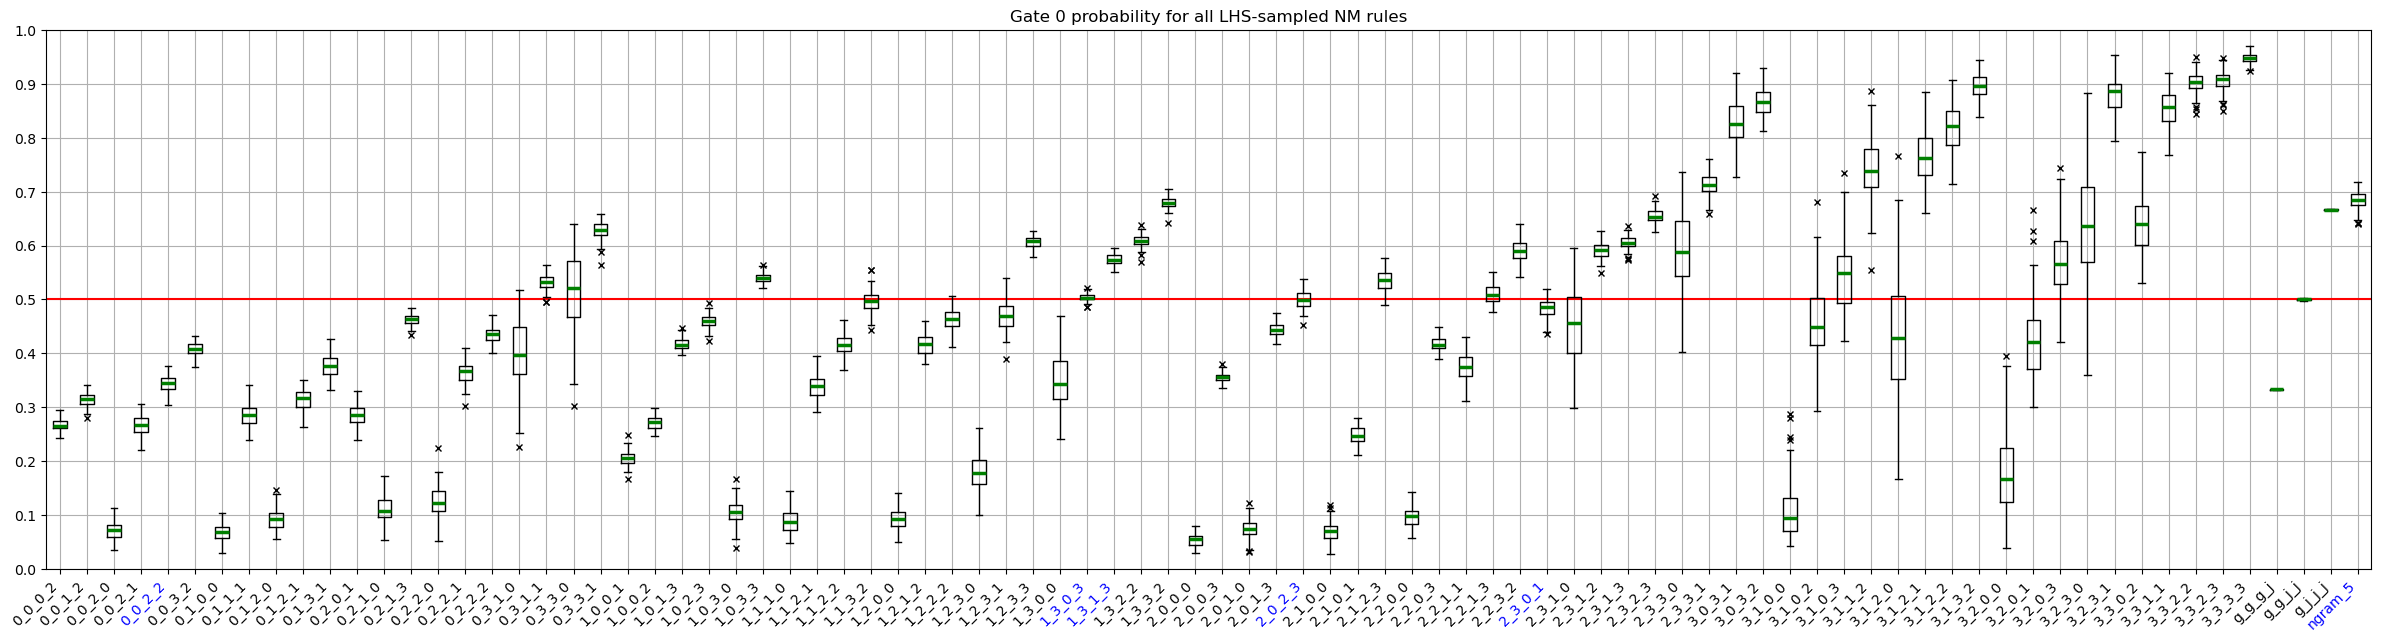

In [35]:
# plot j-gate probabilities for all rules
start, stop = 0, len(NM_gate_probs_all)
labels = list(NM_gate_probs_all.keys())[start:stop]
data = [x[:,0] for x in NM_gate_probs_all.values()][start:stop]

# set customization props
flierprops = dict(marker='x', color='black', markersize=5)
medianprops = dict(lw=2.5, color='green')

# plot figure 
fig, ax = plt.subplots(figsize=(30,7))
ax.set_title('Gate 0 probability for all LHS-sampled NM rules')
ax.axhline(0.5,color='r')
ax.boxplot(data,
            flierprops=flierprops, medianprops=medianprops)
ax.set_yticks(np.arange(0,1.1,0.1))
ax.set_ylim(0,1.0)
ax.set_xticks(range(1, len(labels) + 1), labels, rotation=45, ha='right')

xtick_labels = ax.get_xticklabels()
ticks = ax.get_xticks()
for i,label in enumerate(xtick_labels):
    if label.get_text() in NM_orders_select or label.get_text().startswith('ngram'):
        xtick_labels[i].set_color('b')

plt.grid()
plt.show()

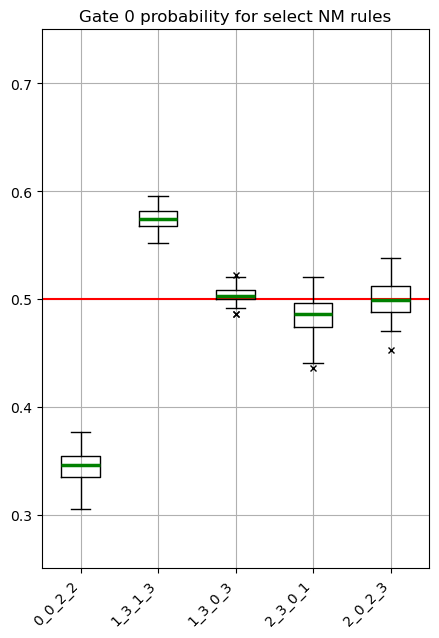

In [36]:
# plot j-gate probabilities for select rules
labels = list(NM_gate_probs_select.keys())
data = [x[:,0] for x in NM_gate_probs_select.values()]

# set customization props
flierprops = dict(marker='x', color='black', markersize=5)
medianprops = dict(lw=2.5, color='green')

# plot figure 
fig, ax = plt.subplots(figsize=(len(data)*1.,7))
ax.set_title('Gate 0 probability for select NM rules')
ax.axhline(0.5,color='r')
ax.boxplot(data,
            flierprops=flierprops, medianprops=medianprops)
ax.set_yticks(np.arange(0,1.1,0.1))
y_epsilon = 0.25
ax.set_ylim(0.5-y_epsilon,0.5+y_epsilon)
ax.set_xticks(range(1, len(labels) + 1), labels, rotation=45, ha='right')

plt.grid()
plt.show()

## Gate probabilities plotting

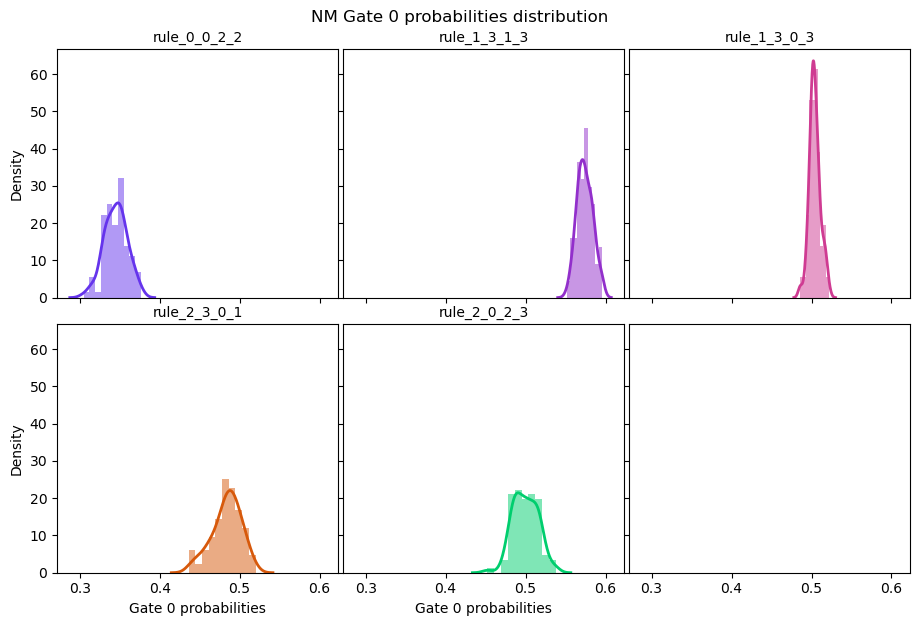

In [37]:
def gate_prob_hists_from_dict(plot_dict, 
                            title,
                            nrows=2,
                            colors = ["#6534EC",
                                    "#922FCB",
                                    "#CF3B92",
                                    "#D7590B",
                                    "#00CE6E",
                                    "#1582CB"]): 
    num_plots = len(plot_dict)
    ncols = int(np.ceil(num_plots/nrows))
    fig, axs = plt.subplots(nrows = nrows, ncols = ncols, 
                        figsize = (ncols * 3.0, nrows * 3.0),
                        sharex=True, sharey=True)
    
    for i, key in enumerate(plot_dict.keys()):
        # plot only p from 1st column, as 2nd column is 1-p
        data = plot_dict[key][:,0]

        row = i // ncols
        col = i % ncols

        sns.histplot(data=data, kde=False, stat='density',bins=10, 
                    color=colors[i],alpha=0.5,edgecolor=None, ax = axs[row][col])
        sns.kdeplot(data=data, color=colors[i], alpha=1, lw=2.0, ax=axs[row][col])
        axs[row][col].set_title(f'rule_{key}',fontsize=10,pad=5)
        axs[row][col].set_xlabel(f'Gate 0 probabilities',fontsize=10)

    fig.suptitle(title,y=1.01)
    plt.tight_layout(pad=0.0)

gate_prob_hists_from_dict(NM_gate_probs_select,title='NM Gate 0 probabilities distribution')
plt.savefig(f'{FIGURES_FILEPATH}NM_gate_probs_separate.png',dpi=150)

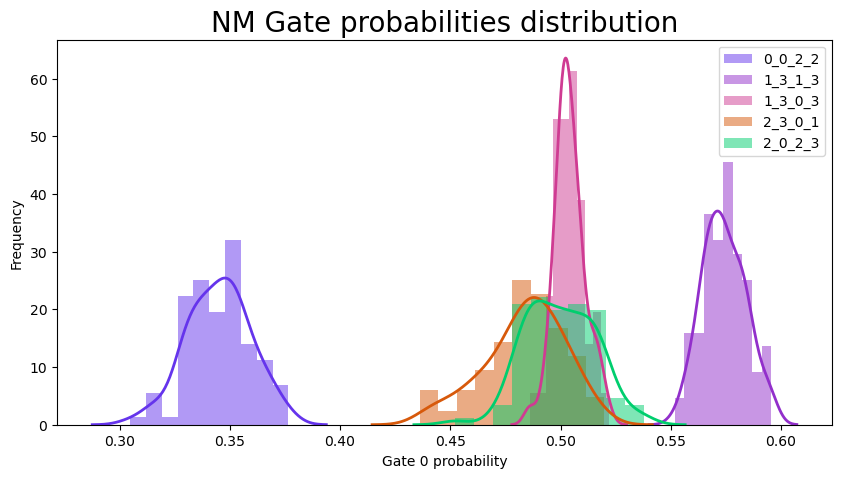

In [38]:
def gate_prob_overlay_hist_from_dict(plot_dict, 
                                    title, 
                                    save_name=None,
                                    probabilities = [0.05, 0.3, 0.5, 0.95],
                                    colors = ["#6534EC",
                                    "#922FCB",
                                    "#CF3B92",
                                    "#D7590B",
                                    "#00CE6E",
                                    "#1582CB"]): 
    num_plots = len(plot_dict)
    fig, ax = plt.subplots(1,1, figsize = (10,5))

    for i,key in enumerate(plot_dict.keys()):
        # plot only p from 1st column, as 2nd column is 1-p
        data = plot_dict[key][:,0]

        sns.histplot(data=data, kde=False, stat='density',bins=10, 
                    color=colors[i], alpha = 0.5, edgecolor=None, 
                    ax = ax,
                    label=key,
        )
        sns.kdeplot(data=data, 
                    color=colors[i], alpha=1, lw=2.0, 
                    ax=ax
                    )

    plt.title(title,fontsize=20)
    plt.legend(fontsize=10)
    ax.set_xlabel('Gate 0 probability')
    ax.set_ylabel('Frequency')

    if save_name:
        plt.savefig(f'{FIGURES_FILEPATH}{save_name}.png',dpi=200)
    plt.show()

gate_prob_overlay_hist_from_dict(NM_gate_probs_select,
                        title='NM Gate probabilities distribution',
                        save_name='NM_gate_probs_hist_combined')

# n-gram testing

In [106]:
def learn_n_gram(str_lst : list, n : int, states = ['j','g']):
    ''' 
    Tries to learn the structure of an n-gram. 
    Works for however many states there are. 

    str_lst : list of strings, for "observed" n-gram sequence.
    n : int, the n in n-gram
    states : what the states are named. 
    ''' 
    gate_seqs = generate_all_gate_seqs(gates = states, rule_len = n-1)

    obs_log = {k: [] for k in gate_seqs}

    for str in str_lst:
        for i in range(len(str) - n): 
            key = tuple(str[i:i+n-1]) 
            val = str[i+n-1]

            obs_log[key].append(val)
    
    probs_dict = {} 

    for key in obs_log.keys():
        counts_dict = Counter(obs_log[key])
        total_counts = sum([x for x in counts_dict.values()])
        probs_dict[key] = {k: v / total_counts for k, v in counts_dict.items()}
    
    return probs_dict


In [113]:
# display rule
print('rule:')
rule = two_gram_rules_prob['rule_1_2_1_2']
print(rule)

# generate more strings
num_trials = 500
str_lst = []

for i in range(num_trials):
    str = generate_seq_from_rule_prob(rule,
                                    init=['j','g'],
                                    max_steps=500)
    str_lst.append(str)

# calculate observational probabilities
obs_probs = learn_n_gram(str_lst, n = 3)

for k, v in obs_probs.items():
    assert sum([x for x in v.values()]) == 1.0 # assert that probabilities sum to 1

for key, val_dict in obs_probs.items():
    print(f'{key}: {val_dict['j'] * 100:.3f}%')

rule:
{('j', 'j'): 0.3, ('j', 'g'): 0.5, ('g', 'j'): 0.3, ('g', 'g'): 0.5}
('j', 'j'): 29.480%
('j', 'g'): 49.755%
('g', 'j'): 29.997%
('g', 'g'): 49.973%


In [114]:
obs_probs_dict = {} 

for n in [2,3]:
    obs_probs = learn_n_gram(str_lst, n = n)
    obs_probs_dict[n] = obs_probs

In [115]:
obs_probs_dict[2]

{('j',): {'g': 0.7030016253594545, 'j': 0.2969983746405455},
 ('g',): {'g': 0.5013593748929963, 'j': 0.4986406251070037}}

In [ ]:
str_lst_dict = {n_key: [] for n_key in obs_probs_dict.keys()} 
for n in [2,3]: 
    rule = obs_probs_dict[n]
    rule = {k: v['j'] for k,v in rule.items()}
    for i in range(num_trials):
        str = generate_seq_from_rule_prob(rule,
                                        init=['j','g'],
                                        max_steps=500)
        str_lst_dict[n].append(str)

In [ ]:
# strings generated from learned model
str_lst_dict[2]

['...']